# Visualizador de Perfis de Poço (Well Log Plotter) — OOP

Notebook único, orientado a objetos, com **dois motores gráficos**:
- **Matplotlib** → versão estática
- **Plotly** → versão interativa

Ao rodar, o app pergunta:
1. Qual motor gráfico usar (estático ou interativo);
2. Se você quer o **layout padrão** (8 trilhas, igual ao que já era plotado) ou um **layout personalizado** (você escolhe quantas colunas, quantos logs por coluna, cor, tipo de linha e preenchimento de cada um).

### 1) Instalar dependências

In [1]:
!pip install -q lasio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.5 MB/s eta 0:00:00


### 2) (Opcional) Montar o Google Drive
Rode esta célula apenas se o arquivo `.las` estiver no seu Google Drive.

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### 3) Importar as bibliotecas

In [3]:
import os
from abc import ABC, abstractmethod

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots


### 4) Camada de dados — `WellData`
Carrega um arquivo `.las` (via `lasio`) e guarda os dados em um `DataFrame`.

In [4]:
class WellData:
    """Carrega e guarda os dados de um poço a partir de um arquivo LAS."""

    def __init__(self, file_path: str):
        self.file_path = file_path
        self.name = os.path.basename(file_path)
        self.data = self._load_data()

    def _load_data(self) -> pd.DataFrame:
        try:
            import lasio
            las = lasio.read(self.file_path)
            df = las.df().reset_index()
        except Exception as e:
            print(f"Erro ao carregar o poço {self.name}: {e}")
            return pd.DataFrame()

        # Alguns arquivos LAS usam "DEPT" em vez de "DEPTH"
        if "DEPTH" not in df.columns and "DEPT" in df.columns:
            df = df.rename(columns={"DEPT": "DEPTH"})
        return df

    def has_logs(self, log_names) -> bool:
        return all(name in self.data.columns for name in log_names)


LINESTYLE_MAP = {"solid": "-", "dash": "--", "dot": ":"}


### 5) `BasePlotter` — o "contrato" comum aos dois motores

Um **layout** é uma lista de **trilhas** (tracks). Cada trilha é uma lista de dicionários de log, no formato:
```python
{'name': 'GR', 'color': 'green', 'style': 'solid', 'fill': 'none', 'xlim': (0, 200)}
```
- `style`: `solid` | `dash` | `dot`
- `fill`: `none` (sem preenchimento) | `zero` (preenche até zero) | `stack` (preenche contra a curva anterior da mesma trilha — usado no layout padrão para empilhar as porosidades de RMN)
- `xlim`: opcional, `(min, max)`. Se omitido, a escala é automática (a partir dos dados). Se `min > max`, o eixo fica invertido (convenção comum em perfis de poço, como densidade e sônico).
- `track_special`: opcional, usado só pelo layout padrão para acionar o preenchimento clássico de cruzamento Densidade‑Neutrão.

In [5]:
class BasePlotter(ABC):
    """Classe abstrata: qualquer motor gráfico recebe um WellData + um layout."""

    DEPTH_COL = "DEPTH"

    def __init__(self, well: WellData, layout: list):
        self.well = well
        self.layout = layout

    @abstractmethod
    def plot(self):
        """Renderiza o gráfico completo."""
        raise NotImplementedError

    def _log_exists(self, log_cfg) -> bool:
        return log_cfg["name"] in self.well.data.columns


### 6) Motor estático — `MatplotlibPlotter`

In [6]:
class MatplotlibPlotter(BasePlotter):
    def plot(self):
        df = self.well.data
        depth = df[self.DEPTH_COL]
        num_tracks = len(self.layout)

        fig, axes = plt.subplots(1, num_tracks, figsize=(2.6 * num_tracks, 15), sharey=True)
        if num_tracks == 1:
            axes = [axes]
        fig.suptitle(f"Perfil de Poço: {self.well.name}", fontsize=16, y=1.01)

        for col_idx, track in enumerate(self.layout):
            base_ax = axes[col_idx]
            track_axes = {}          # nome do log -> eixo (p/ pós-processamentos especiais)
            previous_fill_values = None
            n_plotted = 0

            for log_cfg in track:
                log_name = log_cfg["name"]
                if not self._log_exists(log_cfg):
                    print(f"[Aviso] Log '{log_name}' não encontrado em {self.well.name}; ignorado.")
                    continue

                ax = base_ax if n_plotted == 0 else base_ax.twiny()
                track_axes[log_name] = ax

                values = df[log_name]
                color = log_cfg.get("color", "black")
                style = LINESTYLE_MAP.get(log_cfg.get("style", "solid"), "-")
                fill_mode = log_cfg.get("fill", "none")   # none | zero | stack
                xlim = log_cfg.get("xlim")                # None ou (min, max)

                ax.plot(values, depth, color=color, linestyle=style, lw=1.1)
                ax.set_xlabel(log_name, color=color)
                ax.xaxis.label.set_color(color)
                ax.tick_params(axis="x", colors=color)

                if xlim is not None:
                    ax.set_xlim(*xlim)

                # Empilha o eixo (twiny) acima do anterior, como em um perfil composto
                if n_plotted > 0:
                    ax.spines["top"].set_position(("axes", 1.0 + 0.09 * n_plotted))
                    ax.spines["top"].set_edgecolor(color)
                    ax.spines["top"].set_visible(True)

                # --- preenchimento ---
                if fill_mode == "zero":
                    ax.fill_betweenx(depth, values, 0, facecolor=color, alpha=0.35)
                    previous_fill_values = values
                elif fill_mode == "stack":
                    baseline = previous_fill_values if previous_fill_values is not None else 0
                    ax.fill_betweenx(depth, values, baseline, facecolor=color, alpha=0.6)
                    previous_fill_values = values

                n_plotted += 1

            if n_plotted == 0:
                base_ax.set_visible(False)
                continue

            base_ax.grid(which="major", color="lightgrey", linestyle="-")
            base_ax.xaxis.set_ticks_position("top")
            base_ax.xaxis.set_label_position("top")

            special = self._extract_special(track)
            if special == "density_neutron_crossover":
                self._apply_crossover(track_axes, depth)

        axes[0].set_ylim(depth.max(), depth.min())
        axes[0].set_ylabel("Profundidade (m)")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def _extract_special(track):
        for log_cfg in track:
            if "track_special" in log_cfg:
                return log_cfg["track_special"]
        return None

    def _apply_crossover(self, track_axes, depth):
        """Reproduz o preenchimento clássico de cruzamento Densidade-Neutrão."""
        if "RHOB" not in track_axes or "NPHI" not in track_axes:
            return
        df = self.well.data
        rhob = df["RHOB"]
        nphi = df["NPHI"]

        ax_rhob = track_axes["RHOB"]
        ax_nphi = track_axes["NPHI"]

        x = np.array(ax_rhob.get_xlim())
        z = np.array(ax_nphi.get_xlim())
        nphi_rescaled = ((nphi - np.max(z)) / (np.min(z) - np.max(z))) * (np.max(x) - np.min(x)) + np.min(x)

        # As duas curvas (rhob e nphi_rescaled) já estão na escala do eixo do RHOB.
        # Por isso os DOIS preenchimentos precisam ser feitos nesse MESMO eixo
        # (ax_rhob) - se um deles for desenhado no eixo do NPHI, que tem uma escala
        # diferente, ele fica invisível (fora da área visível daquele eixo).
        ax_rhob.fill_betweenx(depth, rhob, nphi_rescaled, where=(rhob >= nphi_rescaled),
                               interpolate=True, color="green", alpha=0.5, zorder=2)
        ax_rhob.fill_betweenx(depth, rhob, nphi_rescaled, where=(rhob < nphi_rescaled),
                               interpolate=True, color="#e6dc00", alpha=0.6, zorder=2)


### 7) Motor interativo — `PlotlyPlotter`

O Plotly não tem um equivalente nativo ao `twiny()` do Matplotlib: cada célula de subplot só tem um eixo-X por padrão. Para permitir várias curvas com escalas diferentes na mesma trilha, cada curva extra ganha um **eixo-X próprio, sobreposto** (`overlaying`) ao eixo-base daquela coluna e **empilhado visualmente acima do gráfico** (`anchor='free'`, `position=...`) — o mesmo efeito visual do `twiny`, só que feito manualmente.

In [7]:
class PlotlyPlotter(BasePlotter):
    def plot(self):
        df = self.well.data
        depth = df[self.DEPTH_COL]
        num_tracks = len(self.layout)

        max_curves_per_track = max((len(t) for t in self.layout), default=1)
        # fração vertical da figura reservada para empilhar os eixos extras
        plot_top = max(0.55, 1 - 0.045 * max_curves_per_track)
        stack_gap = (1 - plot_top) / max(max_curves_per_track, 1)

        fig = make_subplots(rows=1, cols=num_tracks, shared_yaxes=True,
                             horizontal_spacing=min(0.18 / num_tracks, 0.03))
        fig.update_yaxes(domain=[0, plot_top])

        next_axis_num = num_tracks + 1  # ids 1..num_tracks já usados pelas colunas

        for col_idx, track in enumerate(self.layout, start=1):
            base_x_ref = "x" if col_idx == 1 else f"x{col_idx}"
            y_ref = "y" if col_idx == 1 else f"y{col_idx}"

            track_axis_refs = {}
            previous_values = None
            plotted_k = 0

            for log_cfg in track:
                log_name = log_cfg["name"]
                if not self._log_exists(log_cfg):
                    print(f"[Aviso] Log '{log_name}' não encontrado em {self.well.name}; ignorado.")
                    continue

                values = df[log_name]
                color = log_cfg.get("color", "black")
                style = log_cfg.get("style", "solid")
                fill_mode = log_cfg.get("fill", "none")
                xlim = log_cfg.get("xlim")

                if plotted_k == 0:
                    x_ref = base_x_ref
                    fig.update_xaxes(
                        row=1, col=col_idx, side="top", title_text=log_name,
                        color=color, tickfont=dict(color=color),
                        range=list(xlim) if xlim else None,
                    )
                else:
                    axis_num = next_axis_num
                    next_axis_num += 1
                    x_ref = f"x{axis_num}"
                    fig.update_layout(**{
                        f"xaxis{axis_num}": dict(
                            overlaying=base_x_ref, anchor="free", side="top",
                            position=plot_top + plotted_k * stack_gap,
                            title=dict(text=log_name, font=dict(color=color)),
                            tickfont=dict(color=color),
                            range=list(xlim) if xlim else None,
                            showgrid=False,
                        )
                    })

                track_axis_refs[log_name] = x_ref

                fig.add_trace(
                    go.Scatter(x=values, y=depth, xaxis=x_ref, yaxis=y_ref,
                               name=log_name, mode="lines",
                               line=dict(color=color, dash=style, width=1.5)),
                )

                if fill_mode == "zero":
                    self._add_fill(fig, depth, [0] * len(depth), values, color, x_ref, y_ref, alpha=0.35)
                    previous_values = values
                elif fill_mode == "stack":
                    baseline = previous_values if previous_values is not None else pd.Series([0] * len(depth))
                    self._add_fill(fig, depth, baseline, values, color, x_ref, y_ref, alpha=0.55)
                    previous_values = values

                plotted_k += 1

            if plotted_k == 0:
                continue

            special = self._extract_special(track)
            if special == "density_neutron_crossover":
                self._apply_crossover(fig, track, track_axis_refs, y_ref, depth, df)

        fig.update_yaxes(autorange="reversed", title_text="Profundidade (m)", row=1, col=1)
        fig.update_layout(
            title_text=f"Perfil de Poço Interativo: {self.well.name}",
            height=950,
            width=max(950, 190 * num_tracks),
            template="plotly_white",
            showlegend=False,
            margin=dict(t=90 + 18 * max_curves_per_track),
        )
        fig.show()
        return fig

    @staticmethod
    def _add_fill(fig, depth, baseline, values, color, x_ref, y_ref, alpha):
        fig.add_trace(go.Scatter(x=baseline, y=depth, xaxis=x_ref, yaxis=y_ref,
                                  mode="lines", line=dict(width=0),
                                  showlegend=False, hoverinfo="skip"))
        fig.add_trace(go.Scatter(x=values, y=depth, xaxis=x_ref, yaxis=y_ref,
                                  mode="lines", line=dict(width=0), fill="tonextx",
                                  fillcolor=PlotlyPlotter._to_rgba(color, alpha),
                                  showlegend=False, hoverinfo="skip"))

    @staticmethod
    def _extract_special(track):
        for log_cfg in track:
            if "track_special" in log_cfg:
                return log_cfg["track_special"]
        return None

    @staticmethod
    def _to_rgba(color, alpha):
        import matplotlib.colors as mcolors
        r, g, b = mcolors.to_rgb(color)
        return f"rgba({int(r*255)},{int(g*255)},{int(b*255)},{alpha})"

    def _apply_crossover(self, fig, track, track_axis_refs, y_ref, depth, df):
        """Reproduz o cruzamento Densidade-Neutrão, com preenchimento por segmentos.

        Assim como na versão Matplotlib: a curva de NPHI reescalada (nz) já está
        na ESCALA do eixo do RHOB, então os dois preenchimentos (verde e amarelo)
        precisam usar o eixo-x do RHOB - nunca o do NPHI.
        """
        rhob_cfg = next((c for c in track if c["name"] == "RHOB"), None)
        nphi_cfg = next((c for c in track if c["name"] == "NPHI"), None)
        if rhob_cfg is None or nphi_cfg is None or "RHOB" not in track_axis_refs:
            return
        if "RHOB" not in df.columns or "NPHI" not in df.columns:
            return

        rhob_x_ref = track_axis_refs["RHOB"]

        rhob = df["RHOB"].to_numpy()
        nphi = df["NPHI"].to_numpy()
        d = depth.to_numpy()

        x_min, x_max = rhob_cfg.get("xlim") or (float(np.nanmin(rhob)), float(np.nanmax(rhob)))
        z_min, z_max = nphi_cfg.get("xlim") or (float(np.nanmin(nphi)), float(np.nanmax(nphi)))
        x = np.array([x_min, x_max])
        z = np.array([z_min, z_max])
        nphi_rescaled = ((nphi - np.max(z)) / (np.min(z) - np.max(z))) * (np.max(x) - np.min(x)) + np.min(x)

        condition = rhob >= nphi_rescaled
        change_idx = np.where(np.diff(condition.astype(int)) != 0)[0] + 1
        segments = np.split(np.arange(len(d)), change_idx)

        for seg in segments:
            if len(seg) < 2:
                continue
            color = "rgba(0,200,0,0.45)" if condition[seg[0]] else "rgba(230,210,0,0.55)"
            fig.add_trace(go.Scatter(x=nphi_rescaled[seg], y=d[seg], xaxis=rhob_x_ref, yaxis=y_ref,
                                      mode="lines", line=dict(width=0),
                                      showlegend=False, hoverinfo="skip"))
            fig.add_trace(go.Scatter(x=rhob[seg], y=d[seg], xaxis=rhob_x_ref, yaxis=y_ref,
                                      mode="lines", line=dict(width=0), fill="tonextx",
                                      fillcolor=color, showlegend=False, hoverinfo="skip"))


### 8) Layout padrão (8 trilhas)
Reproduz o layout clássico já usado nos notebooks anteriores: Gamma Ray/Caliper, Gamma Ray espectral, Densidade-Neutrão (com crossover), Porosidade RMN empilhada, Resistividades, Fator Fotoelétrico, Geoquímicos e Sônico.

> **Nota:** o script original tinha os limites do eixo X trocados entre RHOB e NPHI (o que quebrava visualmente o preenchimento de crossover). Aqui os limites foram corrigidos para a convenção padrão da indústria: RHOB de 1.95 a 2.95 g/cm³, NPHI de 0.45 a -0.15 (invertido).

In [8]:
def default_layout() -> list:
    return [
        # Trilha 1: Gamma Ray + Caliper
        [
            {"name": "GR", "color": "green", "style": "solid", "fill": "none", "xlim": (0, 200)},
            {"name": "HCAL", "color": "black", "style": "dash", "fill": "none", "xlim": (6, 20)},
        ],
        # Trilha 2: Gamma Ray Espectral (K, Th, U)
        [
            {"name": "HFK", "color": "#FFEF00", "style": "solid", "fill": "none"},
            {"name": "HTHO", "color": "#09FF00", "style": "dash", "fill": "none"},
            {"name": "HURA", "color": "red", "style": "dot", "fill": "none"},
        ],
        # Trilha 3: Densidade x Neutrão (com crossover clássico)
        [
            {"name": "RHOB", "color": "red", "style": "solid", "fill": "none",
             "xlim": (1.95, 2.95), "track_special": "density_neutron_crossover"},
            {"name": "NPHI", "color": "blue", "style": "solid", "fill": "none",
             "xlim": (0.45, -0.15)},
        ],
        # Trilha 4: Porosidade NMR (preenchimento empilhado)
        [
            {"name": "NMRFL_FINAL", "color": "black", "style": "solid", "fill": "zero", "xlim": (0.4, 0)},
            {"name": "NMRE_FINAL", "color": "#808000", "style": "solid", "fill": "stack", "xlim": (0.4, 0)},
            {"name": "NMRT_FINAL", "color": "#8B4513", "style": "solid", "fill": "stack", "xlim": (0.4, 0)},
        ],
        # Trilha 5: Resistividade (profunda, rasa, média)
        [
            {"name": "RD", "color": "red", "style": "dash", "fill": "none"},
            {"name": "RS", "color": "#FF00E6", "style": "dot", "fill": "none"},
            {"name": "RM", "color": "blue", "style": "solid", "fill": "none"},
        ],
        # Trilha 6: Fator Fotoelétrico
        [
            {"name": "PE", "color": "#FF00E6", "style": "solid", "fill": "none", "xlim": (0, 20)},
        ],
        # Trilha 7: Geoquímicos (Al, Ca, Fe, Mg, Si)
        [
            {"name": "DWAL", "color": "#C0C0C0", "style": "solid", "fill": "zero", "xlim": (0, 0.5)},
            {"name": "DWCA", "color": "#89CFF0", "style": "solid", "fill": "zero", "xlim": (0, 0.5)},
            {"name": "DWFE", "color": "#8B4513", "style": "solid", "fill": "zero", "xlim": (0.5, 0)},
            {"name": "DWMG", "color": "#0077BE", "style": "solid", "fill": "zero", "xlim": (0, 0.5)},
            {"name": "DWSI", "color": "#FFFF00", "style": "solid", "fill": "zero", "xlim": (0.5, 0)},
        ],
        # Trilha 8: Sônico
        [
            {"name": "DT", "color": "#32CD32", "style": "solid", "fill": "none", "xlim": (140, 40)},
        ],
    ]


### 9) Layout personalizado (interface via `input()`)

In [9]:
def build_custom_layout() -> list:
    layout = []
    num_cols = int(input("Quantas colunas (trilhas) você deseja? "))

    for i in range(1, num_cols + 1):
        print(f"\n--- Configurando trilha {i} ---")
        num_logs = int(input(f"Quantos perfis (logs) na trilha {i}? "))
        track = []
        for j in range(1, num_logs + 1):
            print(f"  > Perfil {j} da trilha {i}")
            name = input("    Nome do log (ex: GR, RHOB): ").strip().upper()
            color = input("    Cor da linha (ex: red, blue, #FF00E6): ").strip() or "black"
            style = input("    Tipo de linha [solid/dash/dot]: ").strip().lower() or "solid"
            fill = input("    Preencher a curva até zero? [sim/nao]: ").strip().lower()
            fill_mode = "zero" if fill in ("sim", "s", "yes", "y") else "none"
            track.append({"name": name, "color": color, "style": style, "fill": fill_mode})
        layout.append(track)

    return layout


### 10) Aplicação principal — `WellLogApp`

In [10]:
class WellLogApp:
    def __init__(self, file_path: str):
        self.well = WellData(file_path)

    def run(self):
        if self.well.data.empty:
            print("Encerrando: não foi possível carregar os dados do poço.")
            return

        print("\n=== Visualizador de Perfis de Poço (OOP) ===")
        print(f"Poço carregado: {self.well.name}  |  {len(self.well.data)} amostras\n")

        engine_choice = input(
            "Escolha o motor gráfico:\n"
            "  [1] Estático  (Matplotlib)\n"
            "  [2] Interativo (Plotly)\n"
            "> "
        ).strip()

        layout_choice = input(
            "\nEscolha o layout:\n"
            "  [1] Padrão (8 trilhas)\n"
            "  [2] Criar layout personalizado\n"
            "> "
        ).strip()

        layout = default_layout() if layout_choice != "2" else build_custom_layout()

        plotter_cls = MatplotlibPlotter if engine_choice != "2" else PlotlyPlotter
        plotter = plotter_cls(self.well, layout)
        plotter.plot()


### 11) Executar
Informe o caminho do arquivo `.las` (por exemplo, algo dentro de `/content/drive/MyDrive/...` se você montou o Drive na célula 2).

Caminho do arquivo .las: /content/drive/MyDrive/poços_sapinhoa/9-SPS-95-SP_BASE.las

=== Visualizador de Perfis de Poço (OOP) ===
Poço carregado: 9-SPS-95-SP_BASE.las  |  25581 amostras

Escolha o motor gráfico:
  [1] Estático  (Matplotlib)
  [2] Interativo (Plotly)
> 1

Escolha o layout:
  [1] Padrão (8 trilhas)
  [2] Criar layout personalizado
> 1
[Aviso] Log 'DWMG' não encontrado em 9-SPS-95-SP_BASE.las; ignorado.


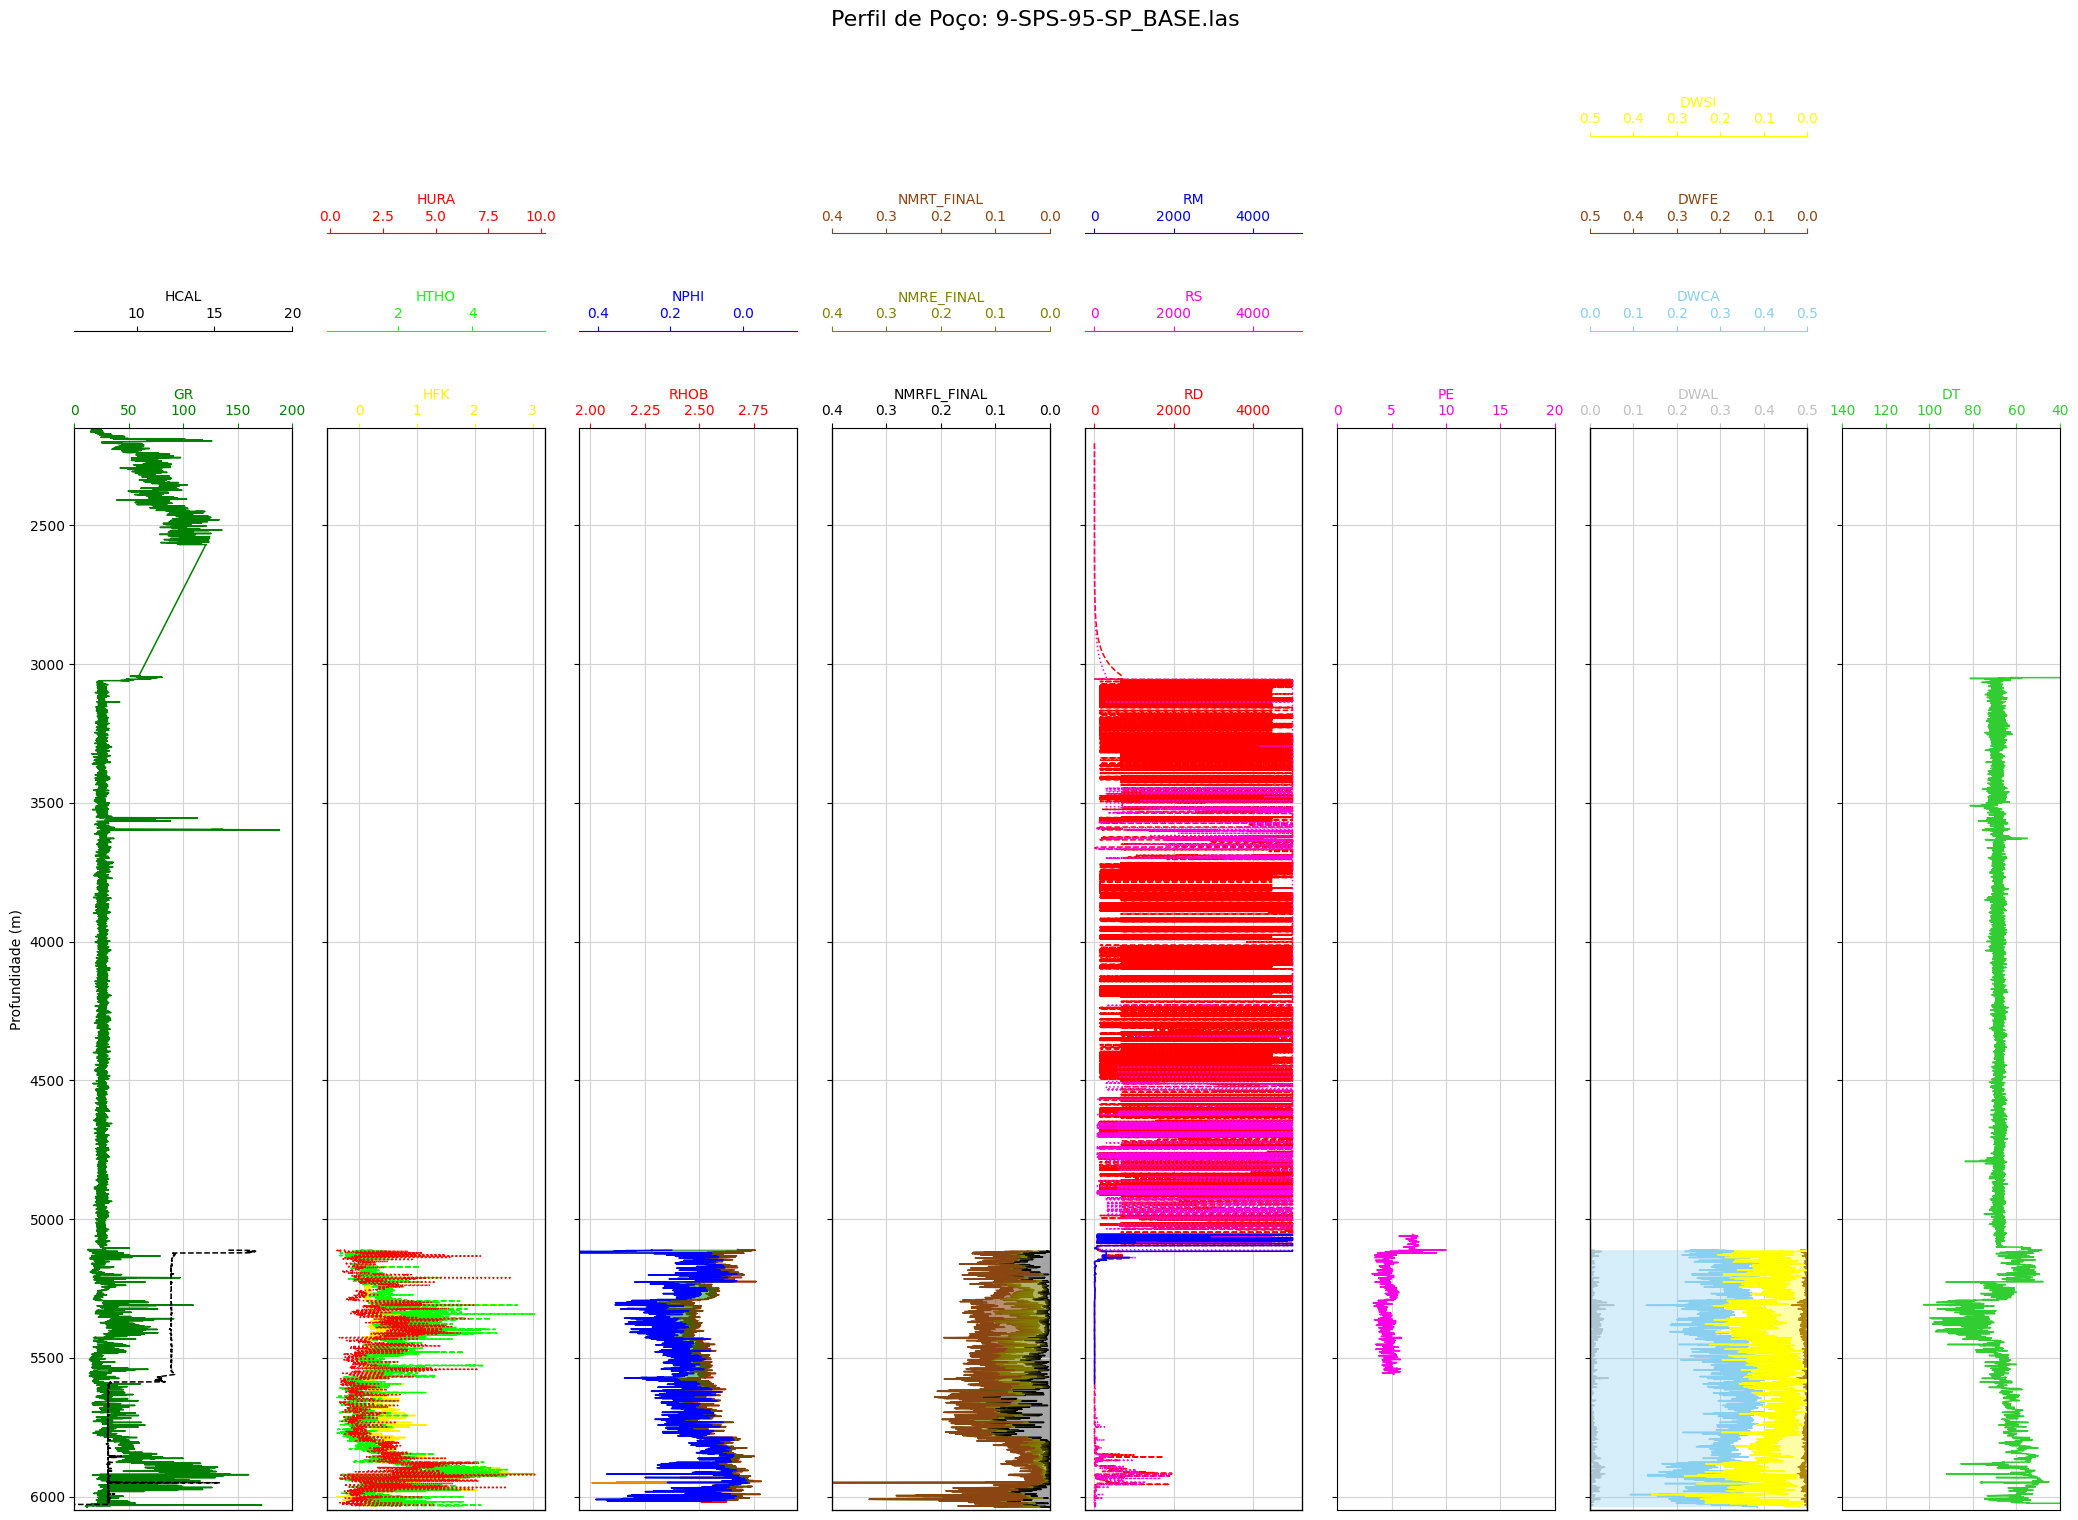

In [13]:
caminho_arquivo_las = input("Caminho do arquivo .las: ").strip()
app = WellLogApp(caminho_arquivo_las)
app.run()
